In [1]:
import pandas as pd

df_model = pd.read_csv("data/processed/accepted_model_base.csv")
print(df_model.shape)

(1371166, 24)


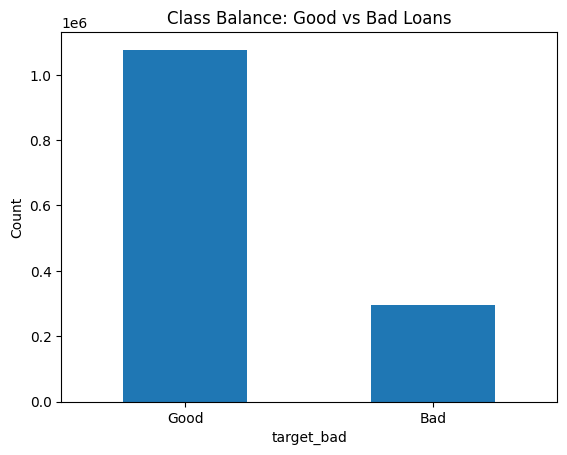

In [2]:
import matplotlib.pyplot as plt

df_model["target_bad"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Good", "Bad"], rotation=0)
plt.ylabel("Count")
plt.title("Class Balance: Good vs Bad Loans")
plt.show()

In [3]:
grade_bad = df_model.groupby("grade")["target_bad"].mean().sort_index()

grade_bad.plot(kind="bar")
plt.ylabel("Bad Rate")
plt.title("Bad Rate by LendingClub Grade")
plt.show()

KeyError: 'grade'

In [ ]:
import matplotlib.pyplot as plt

plot_cols = ["fico_avg", "int_rate", "loan_amnt"]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    good = df_model.loc[df_model["target_bad"] == 0, col].dropna()
    bad = df_model.loc[df_model["target_bad"] == 1, col].dropna()
    
    ax.hist(good, bins=30, alpha=0.6, label="Good")
    ax.hist(bad, bins=30, alpha=0.6, label="Bad")
    ax.set_title(f"{col} by Outcome")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

good = df_model.loc[df_model["target_bad"] == 0, "annual_inc"].dropna()
bad = df_model.loc[df_model["target_bad"] == 1, "annual_inc"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(good), bins=30, alpha=0.6, label="Good", density=True)
plt.hist(np.log1p(bad), bins=30, alpha=0.6, label="Bad", density=True)
plt.xlabel("log(1 + annual_inc)")
plt.ylabel("Density")
plt.title("Log Income by Outcome")
plt.legend()
plt.show()

In [ ]:
numeric_plot_cols = ["fico_avg", "int_rate", "dti", "annual_inc", "loan_amnt"]

for col in numeric_plot_cols:
    plt.figure()
    df_model.boxplot(column=col, by="target_bad")
    plt.title(f"{col} by Loan Outcome")
    plt.suptitle("")
    plt.xlabel("target_bad")
    plt.ylabel(col)
    plt.show()

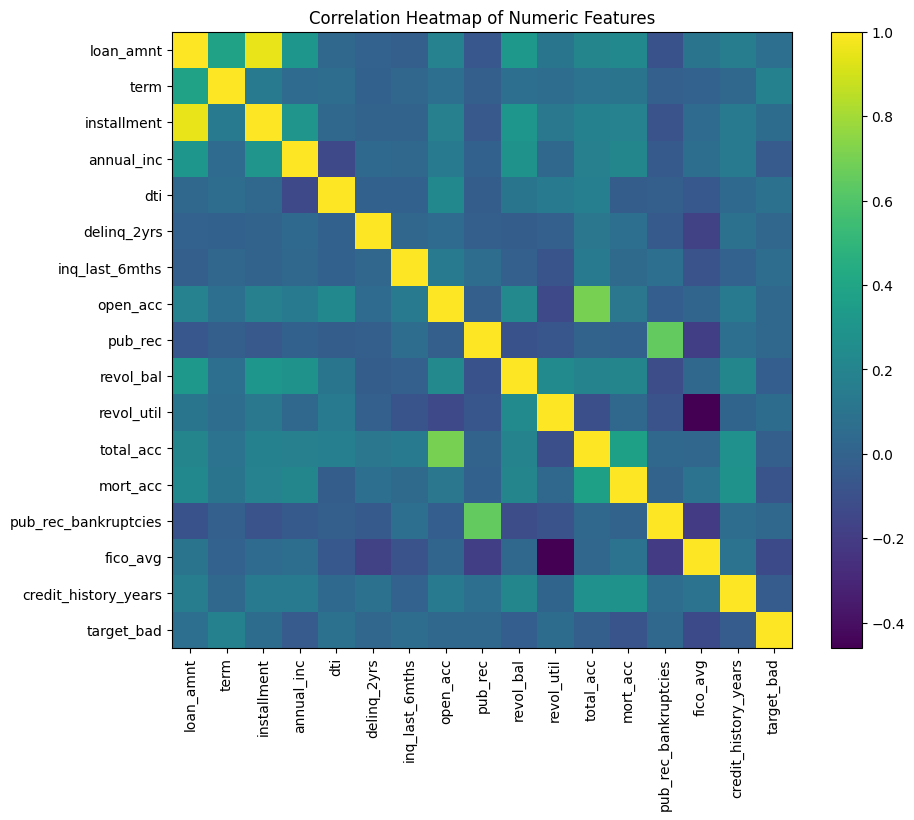

In [4]:
import numpy as np

num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
corr = df_model[num_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()